# NumPy and Matplotlib

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gstonge/csi4124-sys5110/blob/main/notebooks/numpy-matplotlib.ipynb)
[![Open in JupyterLite](https://jupyterlite.rtfd.io/en/latest/_static/badge.svg)](https://www.gstonge.ca/csi4124-sys5110/lite/notebooks/index.html?path=numpy-matplotlib.ipynb)

Two libraries carry almost every numerical task in this course: **NumPy** for arrays and
the arithmetic on them, and **Matplotlib** for figures. This tutorial is a working
introduction to both — about 30 minutes if you run the cells and attempt the exercises.

It assumes you can read Python (variables, functions, loops, lists) but nothing about
either library.

**How to use it:** run each cell in order and read the output. Six exercises marked
**Try it** are yours to write; the text says what result to expect, so you can check
yourself. Change things and re-run — you cannot break anything that a fresh copy
doesn't fix.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

print("numpy", np.__version__)
print("matplotlib", plt.matplotlib.__version__)

numpy 2.2.6
matplotlib 3.10.9


---

# Part 1 — NumPy

## Why an array and not a list?

A Python list holds arbitrary objects and can only be looped over. A NumPy **array**
holds one type of number in one contiguous block, so arithmetic applies to the whole
array at once, in compiled code. That is the entire idea; everything below follows
from it.

## Creating arrays

Build one from a list, or use a constructor when you know the shape you want.

In [2]:
a = np.array([1.0, 2.0, 3.0, 4.0])   # from a Python list

print("zeros:  ", np.zeros(4))            # four 0.0
print("ones:   ", np.ones(3))             # three 1.0
print("full:   ", np.full(3, 7.0))        # filled with a chosen value
print("arange: ", np.arange(0, 10, 2))    # start, stop (excluded), step
print("linspace:", np.linspace(0, 1, 5))  # 5 points, endpoints included

print("\neye(3) — the identity matrix:")
print(np.eye(3))

print("\nzeros((2, 3)) — a shape tuple gives you 2 dimensions:")
print(np.zeros((2, 3)))

zeros:   [0. 0. 0. 0.]
ones:    [1. 1. 1.]
full:    [7. 7. 7.]
arange:  [0 2 4 6 8]
linspace: [0.   0.25 0.5  0.75 1.  ]

eye(3) — the identity matrix:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

zeros((2, 3)) — a shape tuple gives you 2 dimensions:
[[0. 0. 0.]
 [0. 0. 0.]]


`arange` and `linspace` are easy to confuse: `arange` takes a **step**, `linspace`
takes a **number of points** and includes both endpoints. For plotting a smooth curve
you almost always want `linspace`.

## Shape, reshape, transpose

Every array has a `shape` (a tuple), an `ndim` (how many dimensions) and a `dtype`
(what kind of number).

In [3]:
v = np.arange(12)
print("v      :", v)
print("shape  :", v.shape, "| ndim:", v.ndim, "| dtype:", v.dtype)

M = v.reshape(3, 4)          # same 12 numbers, viewed as 3 rows x 4 columns
print("\nM = v.reshape(3, 4):")
print(M)
print("\nM.shape:", M.shape)

print("\nM.T — transpose, 4x3:")
print(M.T)

print("\nreshape(-1) flattens back to 1-D:", M.reshape(-1))

v      : [ 0  1  2  3  4  5  6  7  8  9 10 11]
shape  : (12,) | ndim: 1 | dtype: int64

M = v.reshape(3, 4):
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]

M.shape: (3, 4)

M.T — transpose, 4x3:
[[ 0  4  8]
 [ 1  5  9]
 [ 2  6 10]
 [ 3  7 11]]

reshape(-1) flattens back to 1-D: [ 0  1  2  3  4  5  6  7  8  9 10 11]


`-1` in a reshape means *work this dimension out for me*: `M.reshape(2, -1)` gives
2 rows and however many columns that requires.

## Indexing and slicing

Indexing is zero-based, and `start:stop` **excludes** `stop`. For 2-D arrays, give one
index per dimension, separated by a comma: `M[row, column]`.

In [4]:
v = np.array([10, 20, 30, 40, 50])

print("v[0]    :", v[0])       # first
print("v[-1]   :", v[-1])      # last
print("v[1:4]  :", v[1:4])     # positions 1,2,3 — stop is excluded
print("v[::2]  :", v[::2])     # every second element

print("\nM:"); print(M)
print("\nM[1, 2]  (row 1, column 2):", M[1, 2])
print("M[0]     (whole first row) :", M[0])
print("M[:, 1]  (whole column 1)  :", M[:, 1])
print("M[0:2, 1:3] (a block):"); print(M[0:2, 1:3])

v[0]    : 10
v[-1]   : 50
v[1:4]  : [20 30 40]
v[::2]  : [10 30 50]

M:
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]

M[1, 2]  (row 1, column 2): 6
M[0]     (whole first row) : [0 1 2 3]
M[:, 1]  (whole column 1)  : [1 5 9]
M[0:2, 1:3] (a block):
[[1 2]
 [5 6]]


A `:` on its own means *everything along this dimension*, which is how you take a
whole row or column.

### Boolean masks

Comparing an array with a number gives an array of `True`/`False`, and you can index
with it. This is how you select data by a condition rather than by position.

In [5]:
v = np.array([10, 20, 30, 40, 50])

mask = v > 25
print("mask    :", mask)
print("v[mask] :", v[mask])          # only the elements where mask is True
print("shorthand:", v[v > 25])

print("\ncount above 25:", np.sum(v > 25))   # True counts as 1
print("mean of those   :", v[v > 25].mean())
print("combine with & (and), | (or):", v[(v > 15) & (v < 45)])

mask    : [False False  True  True  True]
v[mask] : [30 40 50]
shorthand: [30 40 50]

count above 25: 3
mean of those   : 40.0
combine with & (and), | (or): [20 30 40]


Use `&` and `|` with parentheses, **not** `and`/`or` — the Python keywords cannot
work element by element and will raise an error.

### Try it 1

Before running anything, **predict** what each of these gives for
`M = np.arange(12).reshape(3, 4)` — both the values and the shape. Then check.

- `M[:, ::2]`
- `M[::-1]`
- `M[M % 3 == 0]`

*Expected: a 3x2 block of the even-numbered columns; the same rows in reverse order;
and a flat array of the four multiples of 3 — note that a mask always returns 1-D,
whatever shape it came from.*

In [6]:
# your turn


## Gotcha 1: a slice is a view, not a copy

This one causes real bugs. A basic slice does not copy data; it is a **view** onto the
same memory. Writing through the view changes the original.

In [7]:
v = np.arange(5)
print("v before:", v)

s = v[1:4]      # a view
s[0] = 99       # write through the view
print("v after :", v, "  <- v changed, even though we assigned to s")

w = np.arange(5)
c = w[1:4].copy()   # ask for a copy explicitly
c[0] = 99
print("\nwith .copy(), w stays:", w)

v before: [0 1 2 3 4]
v after : [ 0 99  2  3  4]   <- v changed, even though we assigned to s

with .copy(), w stays: [0 1 2 3 4]


If you intend to modify a piece of an array without touching the original, say
`.copy()`. (Boolean-mask indexing like `v[v > 25]` already returns a copy.)

## Arithmetic and functions

Operators work element by element, and a scalar applies to every element.

In [8]:
a = np.array([1.0, 2.0, 3.0, 4.0])
b = np.array([10.0, 20.0, 30.0, 40.0])

print("a + b :", a + b)
print("a * b :", a * b)        # element by element, NOT a matrix product
print("b / a :", b / a)
print("a ** 2:", a ** 2)
print("2 * a :", 2 * a)        # the scalar reaches every element

a + b : [11. 22. 33. 44.]
a * b : [ 10.  40.  90. 160.]
b / a : [10. 10. 10. 10.]
a ** 2: [ 1.  4.  9. 16.]
2 * a : [2. 4. 6. 8.]


NumPy's mathematical functions (**ufuncs**) work the same way: give them an array,
get an array back.

In [9]:
x = np.linspace(0, np.pi, 5)

print("x        :", np.round(x, 3))
print("np.sin(x):", np.round(np.sin(x), 3))
print("np.exp(x):", np.round(np.exp(x), 3))
print("np.sqrt  :", np.round(np.sqrt(x), 3))

print("\nnp.pi:", np.pi, "| np.e:", np.e)

x        : [0.    0.785 1.571 2.356 3.142]
np.sin(x): [0.    0.707 1.    0.707 0.   ]
np.exp(x): [ 1.     2.193  4.81  10.551 23.141]
np.sqrt  : [0.    0.886 1.253 1.535 1.772]

np.pi: 3.141592653589793 | np.e: 2.718281828459045


There are many more — `np.cos`, `np.log`, `np.abs`, `np.floor`, `np.maximum` — and
they all follow this pattern. Look them up as you need them rather than memorising.

### Try it 2

Build `x` as 100 points from $0$ to $4$, then compute $f(x) = e^{-x/2}\sin(3x)$.
Print the largest value with `.max()`.

*Expected: about `0.78`.*

In [10]:
# your turn


## Broadcasting

When two arrays have different shapes, NumPy tries to stretch the smaller one. Compare
shapes **right to left**: dimensions must be equal, or one of them must be 1.

`2 * a` above was the simplest case. Here is the useful one — a column and a row
combining into a grid:

In [11]:
col = np.array([[1], [2], [3]])          # shape (3, 1)
row = np.array([[10, 20, 30, 40]])       # shape (1, 4)

print("col.shape:", col.shape, " row.shape:", row.shape)

grid = col + row                          # (3,1) + (1,4) -> (3,4)
print("\ncol + row -> shape", grid.shape)
print(grid)

col.shape: (3, 1)  row.shape: (1, 4)

col + row -> shape (3, 4)
[[11 21 31 41]
 [12 22 32 42]
 [13 23 33 43]]


Read it as: `col` is repeated across 4 columns, `row` is repeated down 3 rows, then
they are added. Nothing is actually copied in memory.

Shapes that cannot be reconciled raise an error, and the message tells you which
dimensions clashed:

```
ValueError: operands could not be broadcast together with shapes (3,) (4,)
```

### Try it 3

Run `np.arange(3) + np.arange(4)` and read the error. Then make it work: turn the
first into a column with `np.arange(3)[:, None]` (the same thing as `.reshape(3, 1)`)
and add them again.

Then use that trick to build a multiplication table for 1 to 5.

*Expected: a (3,4) grid from the first, and a 5x5 table whose last row is
`[5, 10, 15, 20, 25]`.*

In [12]:
# your turn


## Matrix products

`*` is element by element. For a **matrix product** use the `@` operator.

In [13]:
A = np.array([[1.0, 2.0],
              [3.0, 4.0]])
B = np.array([[0.0, 1.0],
              [1.0, 0.0]])

print("A * B — element by element:"); print(A * B)
print("\nA @ B — matrix product:");  print(A @ B)

u = np.array([1.0, 1.0])
print("\nA @ u — matrix times vector:", A @ u)

print("\nA @ eye(2) returns A:"); print(A @ np.eye(2))

A * B — element by element:
[[0. 2.]
 [3. 0.]]

A @ B — matrix product:
[[2. 1.]
 [4. 3.]]

A @ u — matrix times vector: [3. 7.]

A @ eye(2) returns A:
[[1. 2.]
 [3. 4.]]


Mixing these up is one of the most common NumPy mistakes, and it often runs without
error — it just gives the wrong answer. If you mean a matrix product, write `@`.

## Summarising: sum, mean, std, and `axis`

Reductions collapse an array to fewer numbers. With no `axis` you get a single number;
with `axis=` you collapse **that** dimension.

In [14]:
X = np.arange(12).reshape(3, 4)
print("X:"); print(X)

print("\nX.sum():", X.sum(), " X.mean():", X.mean(),
      " X.min():", X.min(), " X.max():", X.max())
print("X.std():", round(X.std(), 3))

print("\nX.sum(axis=0) — collapse the rows, one number per column:", X.sum(axis=0))
print("X.sum(axis=1) — collapse the columns, one number per row :", X.sum(axis=1))

X:
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]

X.sum(): 66  X.mean(): 5.5  X.min(): 0  X.max(): 11
X.std(): 3.452

X.sum(axis=0) — collapse the rows, one number per column: [12 15 18 21]
X.sum(axis=1) — collapse the columns, one number per row : [ 6 22 38]


The rule worth remembering: **`axis` names the dimension that disappears.** `X` has
shape `(3, 4)`; `axis=0` removes the 3 and leaves 4 numbers.

`argmin` and `argmax` give the *position* of the smallest and largest values, which is
often more useful than the value itself.

In [15]:
y = np.array([3.0, 9.0, 1.0, 7.0])
print("max value   :", y.max())
print("its position:", y.argmax())
print("sorted      :", np.sort(y))

print("\ncumsum — running total :", np.cumsum(y))
print("diff   — successive gaps:", np.diff(y))

max value   : 9.0
its position: 1
sorted      : [1. 3. 7. 9.]

cumsum — running total : [ 3. 12. 13. 20.]
diff   — successive gaps: [ 6. -8.  6.]


`np.cumsum` and `np.diff` are inverses of each other, and both come up constantly
once you are working with sequences of measurements.

### Try it 4

`X` above has shape `(3, 4)`. Compute the **mean of each column** and the **maximum of
each row**.

*Expected: four column means `[4, 5, 6, 7]`, and three row maxima `[3, 7, 11]`.*

In [16]:
# your turn


## Gotcha 2: loops are slow, arrays are fast

The reason to use NumPy at all. Same computation, two ways:

In [17]:
import time

n = 500_000
xs = np.arange(n, dtype=float)

t0 = time.perf_counter()
total_loop = 0.0
for value in xs:
    total_loop += value * value
t1 = time.perf_counter()

total_vec = (xs * xs).sum()
t2 = time.perf_counter()

print(f"Python loop: {t1 - t0:.4f} s")
print(f"NumPy      : {t2 - t1:.4f} s")
print(f"speed-up   : {(t1 - t0) / (t2 - t1):.0f}x")
print(f"same answer: {np.isclose(total_loop, total_vec)}")

Python loop: 0.0506 s
NumPy      : 0.0006 s
speed-up   : 80x
same answer: True


The gap grows with `n`. When you catch yourself writing a `for` loop over array
elements, look for the array operation that replaces it.

---

# Part 2 — Matplotlib

## The quick way: `plt.plot`

For a single throwaway figure, the `plt` functions are the shortest path. Each call
draws onto the "current" figure.

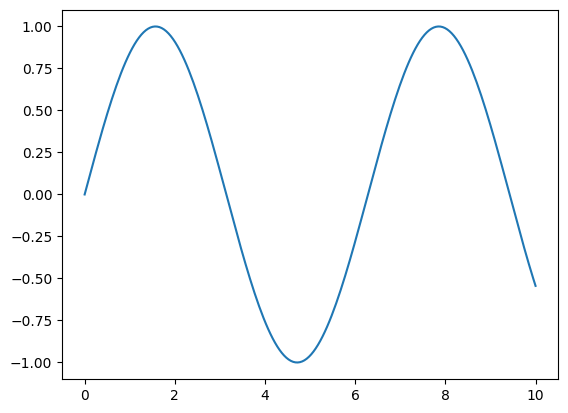

In [18]:
x = np.linspace(0, 10, 200)

plt.plot(x, np.sin(x))
plt.show()

## Labels, legend, title

A plot without axis labels is unreadable. Add a `label=` to each curve and call
`legend()` to explain them.

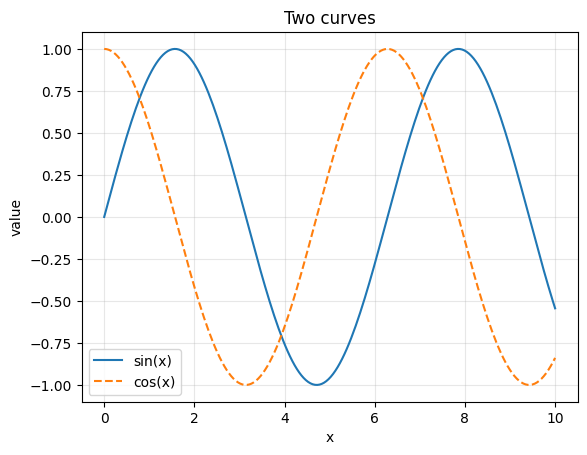

In [19]:
plt.plot(x, np.sin(x), label="sin(x)")
plt.plot(x, np.cos(x), label="cos(x)", linestyle="--")

plt.xlabel("x")
plt.ylabel("value")
plt.title("Two curves")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Useful arguments to `plot`: `color="tab:red"`, `linestyle="--"` (also `":"`, `"-."`),
`linewidth=2`, `marker="o"`, `alpha=0.5` for transparency.

### Try it 5

Plot $e^{-x/3}$ and $e^{-x}$ over the same `x`, each with a label, plus axis labels,
a title and a legend.

*Expected: two decaying curves, the second falling faster.*

In [20]:
# your turn


## The object-oriented way: `fig, ax = plt.subplots()`

`plt.plot` writes to whichever figure is "current", which becomes ambiguous as soon as
you have more than one. The explicit form hands you the objects:

- a **figure** — the whole canvas,
- one or more **axes** — a single set of x/y axes you draw on.

Method names change slightly: `plt.xlabel(...)` becomes `ax.set_xlabel(...)`.

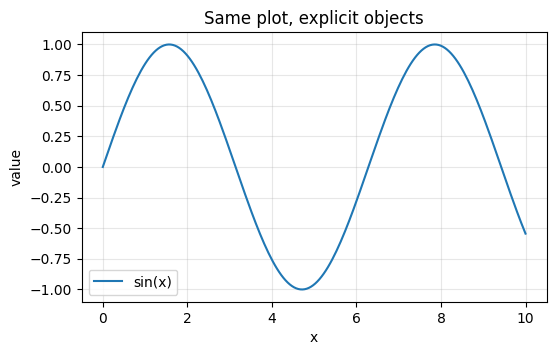

In [21]:
fig, ax = plt.subplots(figsize=(6, 3.5))

ax.plot(x, np.sin(x), label="sin(x)")
ax.set_xlabel("x")
ax.set_ylabel("value")
ax.set_title("Same plot, explicit objects")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

`figsize=(width, height)` is in inches. Use this form by default — everything below
needs it.

## Several panels in one figure

`plt.subplots(rows, columns)` returns the figure and an array of axes.

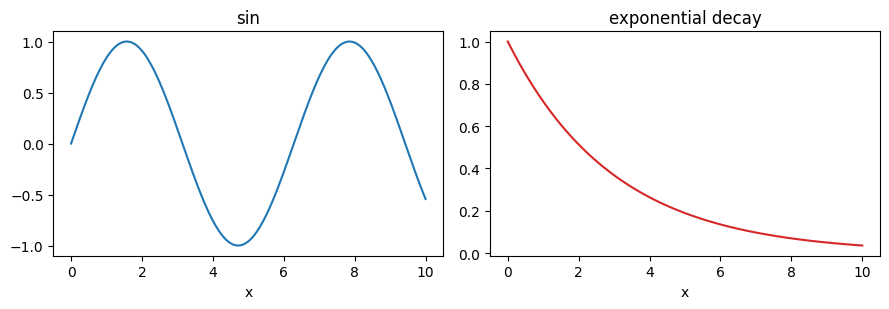

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))

axes[0].plot(x, np.sin(x), color="tab:blue")
axes[0].set_title("sin")
axes[0].set_xlabel("x")

axes[1].plot(x, np.exp(-x / 3), color="tab:red")
axes[1].set_title("exponential decay")
axes[1].set_xlabel("x")

fig.tight_layout()     # stop the labels overlapping
plt.show()

With two rows and two columns, `axes` is 2-D and you index it as `axes[0, 1]`:

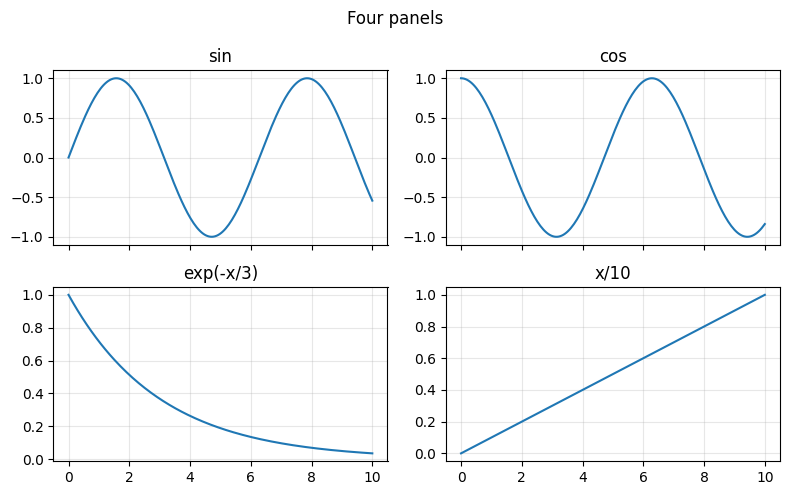

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(8, 5), sharex=True)

funcs = [(np.sin, "sin"), (np.cos, "cos"),
         (lambda t: np.exp(-t / 3), "exp(-x/3)"),
         (lambda t: t / 10, "x/10")]

for ax, (f, name) in zip(axes.flat, funcs):
    ax.plot(x, f(x))
    ax.set_title(name)
    ax.grid(True, alpha=0.3)

fig.suptitle("Four panels")
fig.tight_layout()
plt.show()

`axes.flat` iterates over the panels regardless of the grid shape, and `sharex=True`
ties the x-axes together so they zoom and label consistently.

### Try it 6

Open-ended — nothing to get right. Take the two-curve plot from Try it 5 and
experiment until it reads well **projected on a screen at the back of a room**:

- `linestyle=":"` or `"-."`, `linewidth=3`, `marker="o"` with `markersize`
- `color="tab:green"`, `alpha=0.5`
- `figsize=(3, 3)` versus `(10, 3)` — which shape suits two decaying curves?
- `ax.set_xlim(0, 3)` to zoom in on the early part

*Look for: thicker lines and fewer decorations survive projection, and markers on a
200-point curve turn into a smear.*

In [24]:
# your turn


## Histograms and scatter plots

Two workhorses for looking at data rather than at a function.

*(The cell below uses NumPy's random number generator only to have some numbers to
plot. Generating random values properly — and why the seed matters — is a topic of
its own later in the course.)*

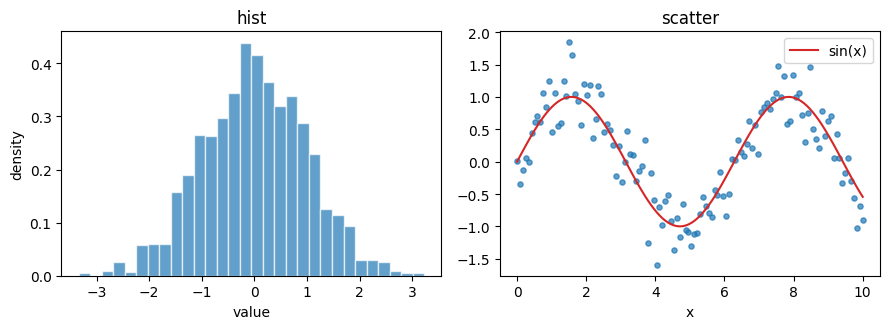

In [25]:
rng = np.random.default_rng(4124)
samples = rng.normal(loc=0.0, scale=1.0, size=2000)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))

axes[0].hist(samples, bins=30, density=True, alpha=0.7, edgecolor="white")
axes[0].set_xlabel("value")
axes[0].set_ylabel("density")
axes[0].set_title("hist")

noise = rng.normal(scale=0.3, size=120)
xs = np.linspace(0, 10, 120)
axes[1].scatter(xs, np.sin(xs) + noise, s=14, alpha=0.7)
axes[1].plot(xs, np.sin(xs), color="tab:red", label="sin(x)")
axes[1].set_xlabel("x")
axes[1].set_title("scatter")
axes[1].legend()

fig.tight_layout()
plt.show()

`bins=` controls the resolution of a histogram, and `density=True` normalises the
area to 1 so it can be compared against a probability density. For `scatter`, `s=` is
the marker area and `alpha=` helps when points overlap.

## Step plots

When a quantity changes instantly and then holds — a count that goes up by one and
stays there — a line plot lies about what happened between the points. `ax.step` with
`where="post"` draws it correctly.

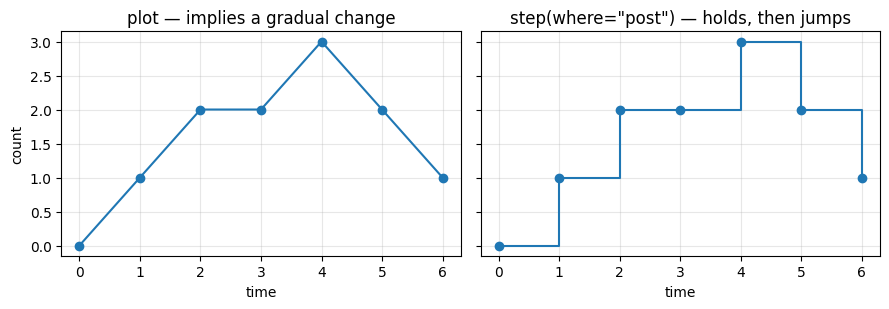

In [26]:
t = np.array([0, 1, 2, 3, 4, 5, 6])
count = np.array([0, 1, 2, 2, 3, 2, 1])

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), sharey=True)

axes[0].plot(t, count, marker="o")
axes[0].set_title("plot — implies a gradual change")

axes[1].step(t, count, where="post", marker="o")
axes[1].set_title('step(where="post") — holds, then jumps')

for ax in axes:
    ax.set_xlabel("time")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("count")

fig.tight_layout()
plt.show()

`where="post"` means the value holds *after* each point until the next one, which is
what a quantity that changes at discrete moments actually does.

## Showing spread: bands and error bars

A single curve rarely tells the whole story. `fill_between` shades a region between
two curves; `errorbar` draws explicit bars.

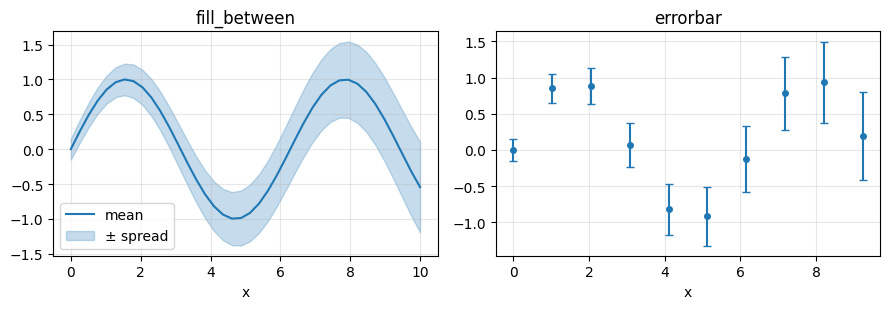

In [27]:
xs = np.linspace(0, 10, 40)
mean = np.sin(xs)
spread = 0.15 + 0.05 * xs

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))

axes[0].plot(xs, mean, color="tab:blue", label="mean")
axes[0].fill_between(xs, mean - spread, mean + spread,
                     alpha=0.25, color="tab:blue", label="± spread")
axes[0].set_title("fill_between")
axes[0].legend()

axes[1].errorbar(xs[::4], mean[::4], yerr=spread[::4],
                 fmt="o", capsize=3, markersize=4)
axes[1].set_title("errorbar")

for ax in axes:
    ax.set_xlabel("x")
    ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## Limits, scales and ticks

Set the visible range with `set_xlim` / `set_ylim`, and switch an axis to logarithmic
with `set_yscale("log")` — essential when values span orders of magnitude.

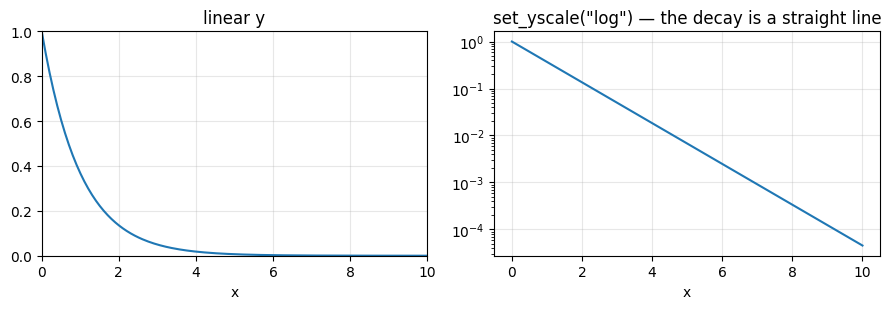

In [28]:
z = np.linspace(0, 10, 200)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))

axes[0].plot(z, np.exp(-z))
axes[0].set_title("linear y")
axes[0].set_xlim(0, 10)
axes[0].set_ylim(0, 1)

axes[1].plot(z, np.exp(-z))
axes[1].set_yscale("log")
axes[1].set_title('set_yscale("log") — the decay is a straight line')
axes[1].set_xticks([0, 2, 4, 6, 8, 10])

for ax in axes:
    ax.set_xlabel("x")
    ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## Saving a figure

`fig.savefig` writes the figure to a file. `bbox_inches="tight"` trims the surrounding
whitespace, and `dpi` controls resolution for raster formats.

saved my-figure.png


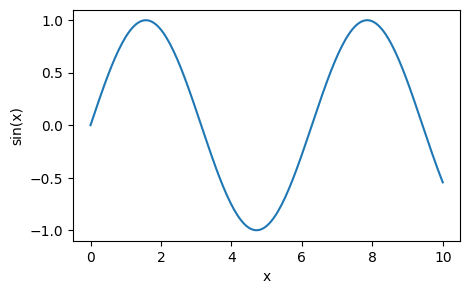

In [29]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x, np.sin(x))
ax.set_xlabel("x")
ax.set_ylabel("sin(x)")

fig.savefig("my-figure.png", dpi=200, bbox_inches="tight")
# fig.savefig("my-figure.pdf", bbox_inches="tight")   # vector, best for reports

print("saved my-figure.png")
plt.show()

For anything you submit, prefer `.pdf` — it stays sharp at any zoom.

Where the file lands depends on where you are running: in Colab it goes to the session's
temporary disk (find it in the file browser on the left), and in JupyterLite it goes to
your browser's storage. Neither survives forever, so download anything you need to keep.

### Try it 7

Make a **two-panel** figure, 1 row by 2 columns:

- left: a histogram of `rng.normal(size=1000)` with 25 bins,
- right: a step plot of `count` against `t` from the step-plot cell above.

Give both panels axis labels and a title, call `fig.tight_layout()`, and save it as
`exercise.png`.

*Expected: a bell-shaped histogram beside a staircase, saved without a border of
whitespace.*

In [30]:
# your turn


### Try it 8

A last exploration: build a 2x2 figure showing how one plotting choice changes what
you see.

- top-left: histogram of `rng.normal(size=2000)` with `bins=5`
- top-right: the same data with `bins=200`
- bottom-left: `np.exp(-z)` for `z = np.linspace(0, 10, 200)`, linear y axis
- bottom-right: the same curve with `set_yscale("log")`

Label every panel and finish with `fig.tight_layout()`.

*Expected: too few bins hides the shape, too many turn it into noise — and the decay
is a straight line only on the log axis. Each pair plots identical data.*

In [31]:
# your turn


---

## Where to look things up

Nobody memorises these libraries. The two references worth bookmarking:

- **NumPy** — [the user guide](https://numpy.org/doc/stable/user/index.html).
  The absolute-beginners page is the first entry, and it broadens from there
- **Matplotlib** — [the example gallery](https://matplotlib.org/stable/gallery/index.html),
  where you find a picture resembling what you want and read its source.
